# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Напишите заголовок первой части проекта здесь

- Автор: Исмаилов Эльчин
- Дата: 19.02.2026

## Цели и задачи проекта

<font color='#777778'>В этом блоке перечислите цель проекта и те задачи, которые вы решаете. Можно использовать описания проекта, но будет полезно, если вы сформулируете основную цель проекта самостоятельно.</font>

**Цель исследования:** выяснить, проводят ли пользователи из Санкт-Петербурга в среднем больше времени на чтение и прослушивание книг в приложении «Яндекс Книги» по сравнению с пользователями из Москвы.

**Задачи исследования:**

1. Проверить, есть ли повторяющиеся идентификаторы пользователей.

2. Сравнить численность групп, их статистические показатели и распределение.

3. Провести анализ гипотезы с использованием t-теста для двух выборок.

4. Выявить уровень статистической значимости (p-value) и интерпретировать результаты теста.

5. Сформулировать заключение на основе значения p-value.

6. Предложить одно или два возможных объяснения для полученных результатов.


## Описание данных

<font color='#777778'>Здесь приведите описание данных.</font>

Информация представлена в **двух файлах**:

1. Файл `ab_test_participants.csv` содержит данные о пользователях, участвующих в A/B-тестах.
   * `user_id`: уникальный идентификатор пользователя.
   * `group`: группа, к которой пользователь относится в рамках конкретного A/B-теста.
   * `ab_test`: название A/B-теста, в котором участвует пользователь.
   * `device`: устройство, с которого пользователь зарегистрировался (например, компьютер или смартфон).


2. Архив `ab_test_events.zip` включает CSV-файл с данными о событиях, произошедших в 2020 году.
   * `user_id`: идентификатор пользователя, связанный с событием.
   * `event_dt`: дата и время события.
   * `event_name`: тип события (например, покупка или просмотр страницы).
   * `details`: дополнительные сведения о событии, которые зависят от его типа.

## Содержимое проекта

<font color='#777778'>Перечислите основные шаги проекта или напишите оглавление. Используйте описание проекта, чтобы зафиксировать основные шаги.</font>

---

1. Сбор и подготовка данных

2. Анализ данных

3. Проверка условий для статистического теста
    
4. Статистическая проверка гипотезы
  
5. Подготовка аналитической запиской


## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from scipy import stats as st
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
# Загрузка данных
users_data = pd.read_csv('yandex_knigi_data.csv')
# test_participants = pd.read_csv('ab_test_participants.csv')
# test_events = pd.read_csv("ab_test_events.zip", sep=';', low_memory=False)

In [3]:
# Предварительная обработка
display("Исходные данные:")
display(users_data.head())

display("\nИнформация о данных:")
display(users_data.info())

display("Список городов:")
display(users_data['city'].unique())

'Исходные данные:'

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


'\nИнформация о данных:'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


None

'Список городов:'

array(['Москва', 'Санкт-Петербург'], dtype=object)

In [4]:
users_data = users_data.drop(columns='Unnamed: 0') #Удалил, потому что лишний столбец, дублирует индекс
display(users_data.head(5))

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [5]:
# Удаление пропусков
df_filtered = users_data[users_data['city'].isin(['Москва', 'Санкт-Петербург'])].dropna(subset=['hours'])

In [6]:
dupl_count = df_filtered['puid'].duplicated().sum()
display(dupl_count)

244

In [7]:
df_clear = df_filtered.drop_duplicates(subset = 'puid', keep = 'first')
display(df_clear.shape)

(8540, 3)

In [8]:
# Проверка пользователей на нахождении в обеих группах
users_moscow = set(df_clear[df_clear['city'] == 'Москва']['puid'].unique())
users_spb = set(df_clear[df_clear['city'] == 'Санкт-Петербург']['puid'].unique())
share_users = users_moscow.intersection(users_spb)

if len(share_users) == 0:
    print("Нет пользователей, которые встречаются в обеих группах") 
else:
    print(f"Количество пользователей в обеих группах: {len(share_users)}")

Нет пользователей, которые встречаются в обеих группах


In [9]:
# Фильтрация данных по городам
moscow_data = df_clear[df_clear['city'] == 'Москва']
spb_data = df_clear[df_clear['city'] == 'Санкт-Петербург']

In [10]:
# Проверка на дубликаты по идентификатору пользователя
display("Дубликаты в Москве:", moscow_data['puid'].duplicated().sum())
display("Дубликаты в Санкт-Петербурге:", spb_data['puid'].duplicated().sum())

'Дубликаты в Москве:'

0

'Дубликаты в Санкт-Петербурге:'

0

In [11]:
# Сравнение размеров групп и статистики
count_moscow = len(moscow_data)
count_spb = len(spb_data)

display("Размер группы Москва:", count_moscow)
display("Размер группы Санкт-Петербург:", count_spb)

'Размер группы Москва:'

6234

'Размер группы Санкт-Петербург:'

2306

In [12]:
distinction = ((count_moscow - count_spb) / count_moscow)*100
display(distinction)

63.0093038177735

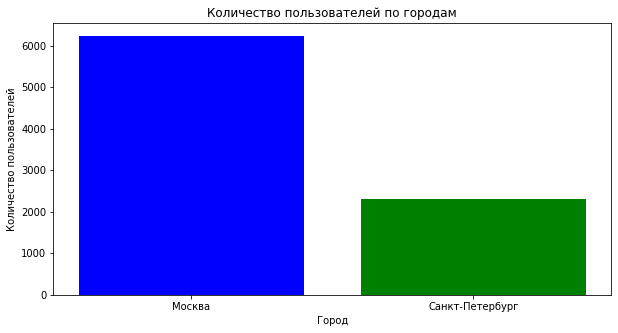

In [13]:
# Создаем список с количествами для графика
counts = [count_moscow, count_spb]

# Названия городов для осей графика
cities = ['Москва', 'Санкт-Петербург']

# Строим график bar
plt.figure(figsize=(10, 5))
plt.bar(cities, counts, color=['blue', 'green'])
plt.title('Количество пользователей по городам')
plt.xlabel('Город')
plt.ylabel('Количество пользователей')
plt.show()

Исходя из вышеописанных вычислений и графика можно сделать вывод, что выборки не равны (в выборке читателей из Москвы более, чем в 2 раза больше пользователей, чем в Санкт-Петербурге). Делаем заключение, что данные в выборке распределены неодинаково, что исключает в дальнейшем использование t-теста Стьюдента.

Следует проверить равенство дисперсий выборок.

In [14]:
# Описательная статистика
display("\nОписательная статистика:")

display("Санкт-Петербург:")
display(spb_data['hours'].describe())

display("\nМосква:")
display(moscow_data['hours'].describe())

'\nОписательная статистика:'

'Санкт-Петербург:'

count    2306.000000
mean       11.264433
std        39.831755
min         0.000025
25%         0.060173
50%         0.875355
75%         6.138424
max       978.764775
Name: hours, dtype: float64

'\nМосква:'

count    6234.000000
mean       10.881092
std        36.851683
min         0.000018
25%         0.059903
50%         0.924498
75%         5.939972
max       857.209373
Name: hours, dtype: float64

In [15]:
dispersion = df_clear.groupby('city')['hours'].var()
display(dispersion)

city
Москва             1358.046537
Санкт-Петербург    1586.568674
Name: hours, dtype: float64

Разброс значений в выборках различается: в Санкт-Петербурге он выше, чем в Москве.

Для проверки гипотезы выбираем t-тест Уэлча. Этот метод не требует, чтобы дисперсии двух выборок были равны, а также не предполагает однородности их распределения.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [16]:
alpha = 0.05
stat_welch_ttest, p_value_welch_ttest = ttest_ind(
    spb_data['hours'],           
    moscow_data['hours'],        
    equal_var=False,     
    alternative='greater' 
)

display(f'pvalue={round(p_value_welch_ttest, 4)}')

if p_value_welch_ttest > alpha:
    print('Нет статистически значимых доказательств, что пользователи СПб читают больше')
else:
    print('Есть статистическки значимые доказательства, что пользователи СПб читают больше')

'pvalue=0.3436'

Нет статистически значимых доказательств, что пользователи СПб читают больше


## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



1. **МЕТОДОЛОГИЯ АНАЛИЗА**

**Статистический метод:** Двухвыборочный t-тест Уэлча для независимых групп.

**Направление теста:** Одностороннее.

**Уровень статистической значимости (α):** 0.05.

**Нулевая гипотеза (H0):**

Среднее время активности пользователей в Санкт-Петербурге не превышает среднего времени активности пользователей в Москве.

**Альтернативная гипотеза (H1):**

Среднее время активности пользователей в Санкт-Петербурге выше, и это различие является статистически значимым.

2. **РЕЗУЛЬТАТЫ ТЕСТА И ВЫВОД**

После проведения t-теста Уэлча для независимых выборок было получено значение **pvalue = 0.3436**, которое **превышает** уровень значимости α = 0.05. На основании сформулированных гипотез можно сделать вывод, что **статистически значимых доказательств** того, что пользователи из Санкт-Петербурга читают больше, чем пользователи из Москвы, **не обнаружено**.

3. **ВОЗМОЖНЫЕ ПРИЧИНЫ**

* **Значительная вариативность данных** внутри каждой группы;

* **Различия в проведении рекламных акций** в каждом городе в зависимости от времени года.

----

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Опишите цели исследования.



Провести A/B-тестирование, чтобы определить, повлияла ли новая версия сайта на показатели.

**Уровень значимости (α)**: 0.05

**Нулевая гипотеза (𝐻0)**:

- Новая версия сайта не привела к значимым изменениям.

**Альтернативная гипотеза (𝐻1)**:

- Новая версия сайта вызвала значимые изменения.

## 2. Загрузите данные, оцените их целостность.


In [ ]:
participants = pd.read_csv('ab_test_participants.csv')
events = pd.read_csv('ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

display(participants.head(5))
display(events.head(5))

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [18]:
#Предварительное знакомство с данными
display(participants.info())
display(events.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


None

In [19]:
# Проверка и удаление дубликатов в датафрейме participants
count_dupl_participants = participants['user_id'].duplicated().sum()

display(count_dupl_participants)

887

In [20]:
participants_clear = participants['user_id'].drop_duplicates()

count_dupl_clear = participants_clear.duplicated().sum()
display(count_dupl_clear)

0

In [21]:
# Проверка дубликатов в датафрейме events по полю 'user_id'
count_dupl_events_userid = events['user_id'].duplicated().sum()
display(count_dupl_events_userid)

643102

In [22]:
# Проверка дубликатов в датафрейме events по полю 'event_dt'
count_dupl_events_eventid = events['event_dt'].duplicated().sum()
display(count_dupl_events_eventid)

180713

Удаление пропусков в датафрейме events **не требуется**, так как повторение индентификаторов пользователей и ивентов позволительны по следующим причинам:

- Один и тот же пользователь мог выполнить несколько действий, которые были зафиксированы системой

- Различные пользователи могли совершить несколько действий.


In [23]:
# Проверка пропусков в датафрейме participants
participants_na = participants_clear.isna().sum()
display(participants_na)

0

In [24]:
# Проверка пропусков в датафрейме events
events_na = events.isna().sum()
display(events_na)

user_id            0
event_dt           0
event_name         0
details       538264
dtype: int64

После загрузки данных из датафрейма и проверки их целостности можно сделать следующие наблюдения:

1. Типы данных в столбцах соответствуют ожидаемым.
2. В датафрейме participants из столбца user_id были удалены дубликаты (всего 887 штук).
3. Пропусков в обоих таблицах не найдено. В столбце details в качестве "заглушки" используется значение Nan.

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [25]:
df_test = participants[participants['ab_test'] == 'interface_eu_test']

display(df_test)
display(f"Общее количество участников теста: {len(df_test)}")

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
2,001064FEAAB631A1,A,interface_eu_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac
5,002412F1EB3F6E38,B,interface_eu_test,Mac
6,002540BE89C930FB,B,interface_eu_test,Android
...,...,...,...,...
14519,FFE600EEC4BA7685,B,interface_eu_test,Android
14520,FFE7FC140521F5F6,A,interface_eu_test,PC
14521,FFEFC0E55C1CCD4F,A,interface_eu_test,PC
14523,FFF28D02B1EACBE1,B,interface_eu_test,PC


'Общее количество участников теста: 10850'

In [26]:
# Проверка равномерности распределения пользователей по группам
counts_group = df_test['group'].value_counts()

display(counts_group)
display(f"\nРазница между кол-вом участников в группах: {abs(counts_group['A'] - counts_group['B']) * 100 / counts_group['A'] :.2f}%")

B    5467
A    5383
Name: group, dtype: int64

'\nРазница между кол-вом участников в группах: 1.56%'

In [27]:
# Проверка отсутствия пересечений с конкурирующей группой
users_A = set(df_test[df_test['group'] == 'A']['user_id'].unique())
users_B = set(df_test[df_test['group'] == 'B']['user_id'].unique())
share_users = users_A.intersection(users_B)

if len(share_users) == 0:
    print("Нет пользователей, которые встречаются в обеих группах") 
else:
    print(f"Количество пользователей в обеих группах: {len(share_users)}")

Нет пользователей, которые встречаются в обеих группах


5383

5467

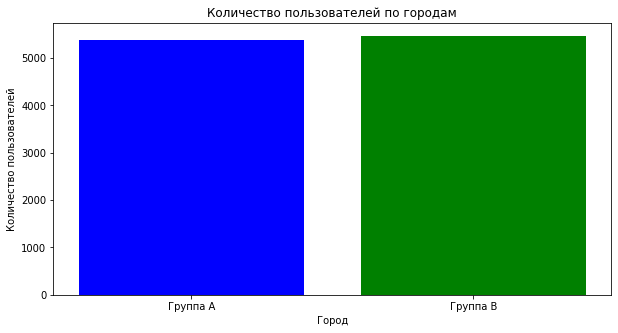

In [28]:
# Создаем список с количествами для графика
counts_A = len(users_A)
counts_B = len(users_B)

display(counts_A, counts_B)

counts = [counts_A, counts_B]

cities = ['Группа А', 'Группа В']

plt.figure(figsize=(10, 5))
plt.bar(cities, counts, color=['blue', 'green'])
plt.title('Количество пользователей по городам')
plt.xlabel('Город')
plt.ylabel('Количество пользователей')
plt.show()

In [29]:
# Рассмотрим распределение в группах по платформам
count_a = df_test[df_test['group'] == 'A']['user_id'].nunique()
df_group_a = df_test[df_test['group'] == 'A']
df_device_a = df_group_a.groupby('device')['user_id'].nunique()
df_part_a = df_device_a / count_a
display(df_part_a)

device
Android    0.454208
Mac        0.105146
PC         0.250046
iPhone     0.190600
Name: user_id, dtype: float64

In [30]:
count_b = df_test[df_test['group'] == 'B']['user_id'].nunique()
df_group_b = df_test[df_test['group'] == 'B']
df_device_b = df_group_b.groupby('device')['user_id'].nunique()
df_part_b = df_device_b / count_b
display(df_part_b)

device
Android    0.441558
Mac        0.101335
PC         0.259374
iPhone     0.197732
Name: user_id, dtype: float64

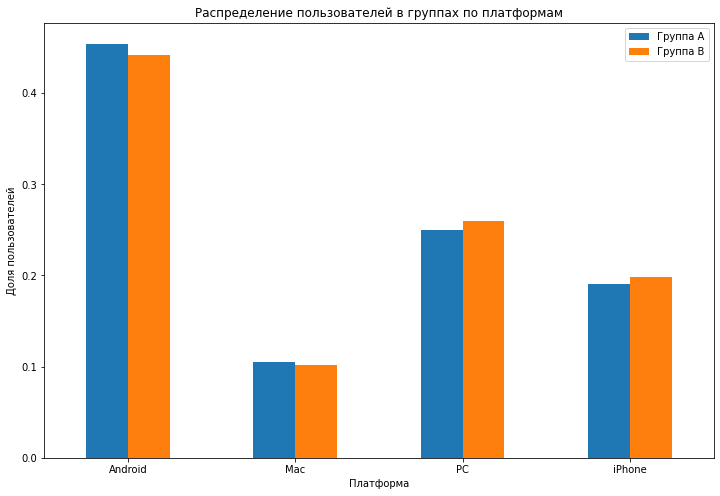

In [31]:
df_dual = pd.concat([df_part_a, df_part_b], axis=1, keys=['Группа A', 'Группа B']).fillna(0)

df_dual.plot(kind='bar', 
             figsize=(12, 8),
             rot=0,
             title='Распределение пользователей в группах по платформам')

plt.xlabel('Платформа')
plt.ylabel('Доля пользователей')
plt.show()

**Промежуточные выводы о правильности проведения теста:**

1. Число участников в каждой группе отличается на 1,56%, что свидетельствует о нормальном распределении данных по группам.
2. Не было выявлено пользователей, которые одновременно принадлежали бы к группам А и В.
3. На представленном графике видно, что пользователи обеих групп равномерно распределены по устройствам.

3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [32]:
ab_test_events = events[events['user_id'].isin(df_test['user_id'])]

display(ab_test_events.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 79715 entries, 64672 to 780371
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     79715 non-null  object        
 1   event_dt    79715 non-null  datetime64[ns]
 2   event_name  79715 non-null  object        
 3   details     21075 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 3.0+ MB


None

- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [33]:
reg_events = ab_test_events[ab_test_events['event_name'] == 'registration']
reg_dates = reg_events.groupby('user_id')['event_dt'].min().reset_index()
reg_dates.columns = ['user_id', 'registration_date']

In [34]:
events_with_reg = ab_test_events.merge(reg_dates, on='user_id', how='left')

In [35]:
events_with_reg['days_since_registration'] = (
    events_with_reg['event_dt'] - events_with_reg['registration_date']
).dt.days

In [36]:
events_by_7_days = events_with_reg[
    (events_with_reg['days_since_registration'] >= 0) &
    (events_with_reg['days_since_registration'] < 7) &
    (events_with_reg['event_name'] != 'registration')
]

display(events_by_7_days)

,user_id,event_dt,event_name,details,registration_date,days_since_registration
16,B13A53A1EB2038EE,2020-12-07 00:04:00,login,NaN,2020-12-06 23:58:03,0
17,4C4BA430AAA820F8,2020-12-07 00:04:30,login,NaN,2020-12-07 00:02:47,0
18,4B7C59A60FE1DA69,2020-12-07 00:04:30,login,NaN,2020-12-07 00:03:51,0
19,4C4BA430AAA820F8,2020-12-07 00:05:26,login,NaN,2020-12-07 00:02:47,0
20,4B7C59A60FE1DA69,2020-12-07 00:05:33,login,NaN,2020-12-07 00:03:51,0
...,...,...,...,...,...,...
79551,E89AF4EFC757D283,2020-12-29 21:46:43,product_cart,NaN,2020-12-23 09:35:48,6
79554,E89AF4EFC757D283,2020-12-29 21:47:56,product_cart,NaN,2020-12-23 09:35:48,6
79628,A6AFDC94A0D3B23D,2020-12-29 22:47:00,product_page,NaN,2020-12-23 13:53:33,6
79634,A6AFDC94A0D3B23D,2020-12-29 22:48:46,product_page,NaN,2020-12-23 13:53:33,6


In [37]:
unique_users = events_by_7_days['user_id'].nunique()

display(unique_users)

10850

Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [38]:
alpha = 0.05  
power = 0.8   
p = 0.3       
mde = 0.03    

effect_size = proportion_effectsize(p, p + mde)

power_analysis = NormalIndPower()

sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1  
)

display(f"Необходимый размер выборки для каждой группы: {round(sample_size)}")
display(f"Общий необходимый размер выборки: {round(sample_size * 2)}")

'Необходимый размер выборки для каждой группы: 3762'

'Общий необходимый размер выборки: 7523'

Необходимый размер выборки: **7 523**.

В финальной выборке обнаружено **10 850** уникальных пользователей. 
Таким образом, условие по размеру выборки **соблюдено**.

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [39]:
# Расчитываем количество покупателей в каждой группе
days_7_users = events_by_7_days['user_id'].unique()

In [40]:
days_7_participants = df_test[df_test['user_id'].isin(days_7_users)]
days_7_ab_test_participants = days_7_participants.groupby('group')['user_id'].nunique()

display(days_7_ab_test_participants)

group
A    5383
B    5467
Name: user_id, dtype: int64

In [41]:
purchasing_users = events_by_7_days[events_by_7_days['event_name'] == 'purchase']['user_id'].unique()

purchasing_participants = df_test[df_test['user_id'].isin(purchasing_users)]
purchasing_visitors = purchasing_participants.groupby('group')['user_id'].nunique()

display(purchasing_visitors)

group
A    1480
B    1600
Name: user_id, dtype: int64

- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

In [42]:
# Расчитываем конверсию в каждой группе
purchasing_visitors_A = purchasing_visitors['A']
purchasing_visitors_B = purchasing_visitors['B']

count_days7_a = days_7_ab_test_participants['A']
count_days7_b = days_7_ab_test_participants['B']

conv_ratio_a = round((purchasing_visitors_A / count_days7_a) * 100, 2)
conv_ratio_b = round((purchasing_visitors_B / count_days7_b) * 100, 2)

display(conv_ratio_a, conv_ratio_b)

27.49

29.27

In [43]:
ratio = round(conv_ratio_b - conv_ratio_a, 2)
ratio_need = 3

display(ratio)

if ratio >= ratio_need:
    print("Фактический прирост конверсии в покупатели больше или равен плановому") 
else:
    print("Фактический прирост конверсии в покупатели меньше планового")

1.78

Фактический прирост конверсии в покупатели меньше планового


За **первые семь дней** после регистрации количество пользователей, совершивших покупку в **группе B**, составило **5 467 человек**, а в **группе A — 5 383 человека**.

В **группе B** количество покупателей достигло **1 600**, а в **группе A — 1 480** человек.

Наблюдается увеличение числа покупателей в группе B по сравнению с группой A примерно на **1.78%**.

## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

In [44]:
n_b, n_a = count_days7_b, count_days7_a
m_b, m_a = purchasing_visitors_B, purchasing_visitors_A

alpha = 0.05

stat_ztest, p_value_ztest = proportions_ztest(
    [m_b, m_a],
    [n_b, n_a],
    alternative='larger'
)

p_value_ztest = round(p_value_ztest, 4)

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение! Распределения метрики в группах A и B не различаются')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения! Распределения метрики в группах A и B различаются')

pvalue=0.0203 < 0.05
Нулевая гипотеза не находит подтверждения! Распределения метрики в группах A и B различаются


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

На основании проведённого анализа можно сделать следующие выводы:

**Нулевая гипотеза** о том, что «новая версия сайта не привела к статистически значимым изменениям», **не подтверждается**. Наблюдаемое **увеличение конверсии** в покупатели **на 1.78%** статистически значимо, что указывает на высокую вероятность успеха при внедрении новой версии сайта.

Ожидаемый эффект составлял **3%**, что выше подтверждённого метриками результата **1.78%**. Это означает, что, хотя изменения в 1.78% статистически значимы, **плановое улучшение не будет достигнуто**.